# Assignment for Thesis technical interview

## Data Loading

In [42]:
# Import libraries
import numpy as np 
import pandas as pd 
import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay, classification_report, mean_absolute_error
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from xgboost import XGBRegressor
import shap

In [2]:
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Load Data
data = pd.read_parquet('/home/sam4ner/Scrivania/THESIS/interview_assignment/US_accidents_dataset_subsample.parquet', engine = 'fastparquet')

## Data Preprocessing

In [5]:
data.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,None,None,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
1,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,None,None,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
2,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,None,None,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day
3,A-7,Source2,2,2016-02-08 07:59:35,2016-02-08 08:29:35,39.758274,-84.230507,None,None,0.00,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-15,Source2,2,2016-02-08 08:39:43,2016-02-08 09:09:43,39.972038,-82.913521,None,None,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [6]:
data.describe()

,Severity,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,978823.000000,741189.000000,977452.000000,981862.000000,977277.000000,925942.000000,715098.000000
mean,2.212410,36.201785,-94.685380,0.561912,61.683230,58.287491,64.836068,29.541428,9.090715,7.688670,0.008416
std,0.487631,5.076235,17.383016,1.811210,19.002175,22.367036,22.806359,0.999807,2.677253,5.436819,0.105850
min,1.000000,24.566999,-124.497420,0.000000,-89.000000,-89.000000,1.000000,0.390000,0.000000,0.000000,0.000000
25%,2.000000,33.398775,-117.214386,0.000000,49.000000,43.000000,48.000000,29.370000,10.000000,4.600000,0.000000
50%,2.000000,35.825378,-87.758950,0.030000,64.000000,62.000000,67.000000,29.860000,10.000000,7.000000,0.000000
75%,2.000000,40.090187,-80.353260,0.462000,76.000000,75.000000,84.000000,30.030000,10.000000,10.400000,0.000000
max,4.000000,49.000504,-67.484130,242.339996,162.000000,162.000000,100.000000,58.630000,100.000000,822.800000,10.110000


In [7]:
print(data.columns)

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')


In [8]:
data.isna().sum()

ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  439887
End_Lng                  439887
Distance(mi)                  0
Description                   0
Street                     1415
City                         37
County                        0
State                         0
Zipcode                     241
Country                       0
Timezone                   1000
Airport_Code               2934
Weather_Timestamp         15547
Temperature(F)            21177
Wind_Chill(F)            258811
Humidity(%)               22548
Pressure(in)              18138
Visibility(mi)            22723
Wind_Direction            22676
Wind_Speed(mph)           74058
Precipitation(in)        284902
Weather_Condition         22397
Amenity                       0
Bump                          0
Crossing

### End Latitude and Longitude

In [9]:
for i, row in data.iterrows():
    if (pd.isna(row['End_Lat']) or pd.isna(row['End_Lng'])): print(row['Distance(mi)'])
    if(i > 1000): break

0.01
0.01
0.01
0.0
0.01
0.01
0.0
0.01
0.0
0.01
0.01
0.01
0.01
0.01
1.28
0.01
0.01
0.48
0.0
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.0
0.01
0.01
0.01
0.0
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.0
0.01
0.01
0.0
0.0
0.0
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.01
0.0
0.01
0.01
0.01
0.01
0.01
0.0
0.01
0.01
0.01
0.0
0.01
0.0
0.01
0.0
0.01
0.01
0.01
0.01
0.01
0.0
0.01
0.01
0.01
0.01
0.01
0.01
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0

In [4]:
mask = (
    (data["End_Lat"].isna() | data["End_Lng"].isna()) &
    (data["Distance(mi)"] <= 0.1)
)

count = data["End_Lat"].isna() | data["End_Lng"].isna()

print(mask.sum() / count.sum())

0.931684728123359


In [5]:
#Since in 93% of the cases, a Null End Latitude / Longitude is associated with an almost 0 distance, we assume that this null value
# are caused by that, so we replace the null values with the corresponding start coordinates
data['End_Lat'] = data['End_Lat'].fillna(data['Start_Lat'])
data['End_Lng'] = data['End_Lng'].fillna(data['Start_Lng'])

### Timestamps

In [6]:
#Let's transform the timestamps in something more useful
data['Start_Time'] = pd.to_datetime(data['Start_Time'], format="ISO8601")
data['End_Time'] = pd.to_datetime(data['End_Time'], format="ISO8601")
data['Weather_Timestamp'] = pd.to_datetime(data['Weather_Timestamp'], format="ISO8601")

In [7]:
data['Start_Time_Hour'] = data['Start_Time'].dt.hour
data['Start_Time_Day'] = data['Start_Time'].dt.dayofweek
data['Start_Time_Month'] = data['Start_Time'].dt.month


data['End_Time_Hour'] = data['End_Time'].dt.hour
data['End_Time_Day'] = data['End_Time'].dt.dayofweek
data['End_Time_Month'] = data['End_Time'].dt.month

data["Accident_Duration"] = (data["End_Time"] - data["Start_Time"]).dt.total_seconds()



In [9]:
(data['Weather_Timestamp']- data['Start_Time']).describe()

count                       984453
mean     0 days 00:00:27.843468403
std      0 days 00:40:42.267031328
min              -1 days +01:16:00
25%              -1 days +23:48:51
50%                0 days 00:00:00
75%                0 days 00:11:23
max                0 days 23:52:00
dtype: object

In [8]:
#Since the mean difference between the Weather time stamps and the Start time is low, it seems reasonable to
# substitute the missing values of the first column with the corresponding values of the second one
data["Weather_Timestamp"] = data["Weather_Timestamp"].fillna(data["Start_Time"])

In [9]:
data['Weather_Time_Hour'] = data['Weather_Timestamp'].dt.hour
data['Weather_Time_Day'] = data['Weather_Timestamp'].dt.dayofweek
data['Weather_Time_Month'] = data['Weather_Timestamp'].dt.month

In [10]:
# hours, days of the week and months are cyclic 

data['Start_Time_Hour_sin'] = np.sin(2*np.pi*data["Start_Time_Hour"]/24)   # 24 hours
data['Start_Time_Day_sin'] = np.sin(2*np.pi*data["Start_Time_Day"]/7)      # 7 days
data['Start_Time_Month_sin'] = np.sin(2*np.pi*data["Start_Time_Month"]/12)   # 12 months

data['End_Time_Hour_sin'] = np.sin(2*np.pi*data["End_Time_Hour"]/24)   
data['End_Time_Day_sin'] = np.sin(2*np.pi*data["End_Time_Day"]/7)     
data['End_Time_Month_sin'] = np.sin(2*np.pi*data["End_Time_Month"]/12) 

data['Weather_Time_Hour_sin'] = np.sin(2*np.pi*data["Weather_Time_Hour"]/24)   
data['Weather_Time_Day_sin'] = np.sin(2*np.pi*data["Weather_Time_Day"]/7)     
data['Weather_Time_Month_sin'] = np.sin(2*np.pi*data["Weather_Time_Month"]/12) 

data['Start_Time_Hour_cos'] = np.cos(2*np.pi*data["Start_Time_Hour"]/24)   # 24 hours
data['Start_Time_Day_cos'] = np.cos(2*np.pi*data["Start_Time_Day"]/7)      # 7 days
data['Start_Time_Month_cos'] = np.cos(2*np.pi*data["Start_Time_Month"]/12)   # 12 months

data['End_Time_Hour_cos'] = np.cos(2*np.pi*data["End_Time_Hour"]/24)   
data['End_Time_Day_cos'] = np.cos(2*np.pi*data["End_Time_Day"]/7)     
data['End_Time_Month_cos'] = np.cos(2*np.pi*data["End_Time_Month"]/12) 

data['Weather_Time_Hour_cos'] = np.cos(2*np.pi*data["Weather_Time_Hour"]/24)   
data['Weather_Time_Day_cos'] = np.cos(2*np.pi*data["Weather_Time_Day"]/7)     
data['Weather_Time_Month_cos'] = np.cos(2*np.pi*data["Weather_Time_Month"]/12) 



In [11]:
# Now we drop the timestamps
data.drop(['Start_Time', 'End_Time', 'Weather_Timestamp', 'Start_Time_Hour', 'Start_Time_Day', 'Start_Time_Month', 'End_Time_Hour', 'End_Time_Day', 'End_Time_Month',
           'Weather_Time_Hour', 'Weather_Time_Day', 'Weather_Time_Month'], inplace=True, axis=1)

### State

In [19]:
print(len(data['State'].unique()))

49


In [20]:
data['State'].value_counts()

State
CA    225127
FL    113732
TX     75670
SC     49455
NY     45191
NC     43419
VA     39056
PA     38472
MN     24954
OR     23216
GA     21997
AZ     21949
TN     21834
IL     21725
MI     21118
LA     19541
NJ     18273
MD     18133
OH     15356
WA     13939
AL     12999
UT     12531
CO     11670
OK     10768
MO     10045
CT      9221
IN      8781
MA      8108
WI      4509
KY      4239
NE      3761
MT      3635
IA      3460
AR      3049
KS      2747
NV      2738
DC      2497
RI      2157
MS      1950
DE      1800
WV      1775
ID      1385
NM      1369
NH      1290
WY       478
ND       414
ME       307
VT       122
SD        38
Name: count, dtype: int64

In [12]:
state_severity = data.groupby('State')['Severity'].mean().sort_values(ascending=False)
print(state_severity.head(10))
print(state_severity.tail(10))

State
GA    2.506296
WI    2.472167
VT    2.467213
RI    2.460825
KY    2.457183
CO    2.452528
IA    2.421676
MO    2.407267
IN    2.395855
IL    2.376341
Name: Severity, dtype: float64
State
DC    2.134962
NC    2.132223
LA    2.125736
AZ    2.125518
OR    2.112035
SC    2.110464
ID    2.091697
OK    2.075594
MT    2.041541
ND    2.007246
Name: Severity, dtype: float64


In [13]:
state_counts = data['State'].value_counts()
state_severity = state_severity.to_frame().join(state_counts.to_frame('count')) # streets with low accidents number are likely to be noise



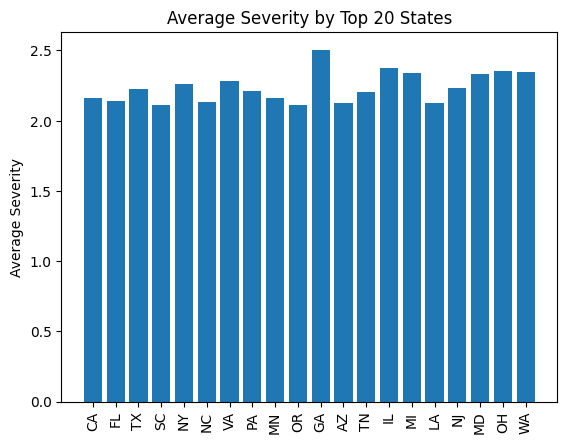

In [14]:
top_states = state_counts.head(20).index
subset = state_severity.loc[top_states]

plt.bar(subset.index, subset['Severity'])
plt.xticks(rotation=90)
plt.ylabel('Average Severity')
plt.title('Average Severity by Top 20 States')
plt.show()

It does not look like there are states where the mean Severity is particularly higher than the other, but we still need to reduce the cardinality to apply one hot encoding, so we keep only the 3 states with most accidents end we aggregate the others in the 'Others' category

In [14]:
frequent_states = ['CA', 'FL', 'TX']

data['grouped_State'] = data['State'].where(data['State'].isin(frequent_states), 'Other')

In [15]:
data = pd.get_dummies(data, columns=['grouped_State'])

In [16]:
data.drop('State', inplace=True, axis=1)

### Street, City, County, Country, Zipcode

This columns have a lot of different unique values and an high granularity. Moreover, spatial informations are already provided by the coordinates. For this reasons we drop them for the moment.

In [17]:
data.drop(['Street', 'City', 'County', 'Country', 'Zipcode'], inplace=True, axis=1)

### Timezone

In [28]:
print(data['Timezone'].unique())

['US/Eastern' 'US/Pacific' None 'US/Central' 'US/Mountain']


In [18]:
# Drop the null values (there's only a thousand)
data = data[data['Timezone'].notna()]

In [19]:
data = pd.get_dummies(data, columns=['Timezone'])

### Airport Code

Following the same reasoning pattern as the States

In [31]:
print(len(data['Airport_Code'].unique()))

1949


In [32]:
data['Airport_Code'].value_counts()

Airport_Code
KCQT    15293
KRDU    13692
KMCJ    13271
KBNA    12809
KCLT    12547
        ...  
KTBX        1
KECS        1
KGNR        1
KBVO        1
KAVK        1
Name: count, Length: 1948, dtype: int64

In [20]:
frequent_airports = ['KCQT', 'KRDU', 'KMCJ', 'KBNA', 'KCLT']

data['grouped_Airports'] = data['Airport_Code'].where(data['Airport_Code'].isin(frequent_airports), 'Other')

In [21]:
data = pd.get_dummies(data, columns=['grouped_Airports'])

In [22]:
data.drop('Airport_Code', inplace=True, axis=1)

### Wind Direction

In [24]:
data['Wind_Direction'].unique() # Duplicated labels

array(['Calm', 'SW', 'WSW', 'SSW', 'West', 'WNW', 'NW', 'NNW', 'SE',
       'South', 'East', 'SSE', 'NE', 'NNE', 'ENE', 'ESE', 'North', 'W',
       'Variable', None, 'S', 'VAR', 'E', 'CALM', 'N'], dtype=object)

In [23]:
data = data.replace(to_replace=['Calm', 'North', 'South', 'West', 'East', 'Variable'], \
            value= ['CALM' ,'N', 'S', 'W', 'E', 'VAR'], inplace=True)

In [38]:
data['Wind_Direction'].unique()

array(['CALM', 'SW', 'WSW', 'SSW', 'W', 'WNW', 'NW', 'NNW', 'SE', 'S',
       'E', 'SSE', 'NE', 'NNE', 'ENE', 'ESE', 'N', 'VAR', None],
      dtype=object)

In [24]:
data['Wind_Direction'] = data['Wind_Direction'].fillna(data['Wind_Direction'].mode())

In [25]:
data = pd.get_dummies(data, columns=['Wind_Direction']) # We could also try with Cyrcular encoding

### Weather Condition

In [41]:
data['Weather_Condition'].unique()

array(['Light Rain', 'Mostly Cloudy', 'Overcast', 'Light Snow', 'Haze',
       'Clear', 'Scattered Clouds', 'Light Freezing Drizzle',
       'Light Drizzle', 'Partly Cloudy', 'Heavy Rain', 'Snow', 'Fog',
       'Rain', None, 'Mist', 'Light Freezing Fog',
       'Light Thunderstorms and Rain', 'Shallow Fog', 'Smoke',
       'Thunderstorms and Rain', 'Fair', 'Cloudy', 'Drizzle',
       'Blowing Dust / Windy', 'Widespread Dust', 'Rain Showers',
       'Patches of Fog', 'Partly Cloudy / Windy', 'Fair / Windy',
       'Thunderstorm', 'Heavy Thunderstorms and Rain',
       'Light Freezing Rain', 'Heavy T-Storm', 'Heavy Snow',
       'Light Ice Pellets', 'Light Rain Showers', 'Ice Pellets',
       'Light Rain / Windy', 'Heavy Drizzle', 'Thunder in the Vicinity',
       'Blowing Snow', 'Cloudy / Windy', 'Rain / Windy',
       'Heavy Rain / Windy', 'N/A Precipitation', 'Small Hail', 'Squalls',
       'Volcanic Ash', 'Thunder', 'Light Rain with Thunder', 'T-Storm',
       'Mostly Cloudy / Windy'

In [26]:
# Text Normalization
data['Weather_Condition'] = (data['Weather_Condition'].str.lower().str.strip())

In [27]:
data['weather_rain'] = data['Weather_Condition'].str.contains('rain', na=False)
data['weather_snow'] = data['Weather_Condition'].str.contains('snow', na=False)
data['weather_fog'] = data['Weather_Condition'].str.contains('fog|mist|haze', na=False)
data['weather_storm'] = data['Weather_Condition'].str.contains('storm|thunder', na=False)
data['weather_windy'] = data['Weather_Condition'].str.contains('windy', na=False)
data['weather_clear'] = data['Weather_Condition'].str.contains('clear|fair', na=False)
data['weather_ice'] = data['Weather_Condition'].str.contains('ice|freezing|sleet', na=False)

In [28]:
data.drop(columns=['Weather_Condition'], inplace=True)

### Light Conditions

In [31]:
print(data['Sunrise_Sunset'].unique())
print(data['Civil_Twilight'].unique())
print(data['Nautical_Twilight'].unique())
print(data['Astronomical_Twilight'].unique())

['Night' 'Day' None]
['Night' 'Day' None]
['Night' 'Day' None]
['Day' 'Night' None]


In [29]:
data['Sunrise_Sunset'] = data['Sunrise_Sunset'].fillna(data['Sunrise_Sunset'].mode())
data['Civil_Twilight'] = data['Civil_Twilight'].fillna(data['Civil_Twilight'].mode())
data['Nautical_Twilight'] = data['Nautical_Twilight'].fillna(data['Nautical_Twilight'].mode())
data['Astronomical_Twilight'] = data['Astronomical_Twilight'].fillna(data['Astronomical_Twilight'].mode())

In [30]:
data['Sunrise_Sunset'] = (data['Sunrise_Sunset'] == 'Day')
data['Civil_Twilight'] = (data['Civil_Twilight'] == 'Day')
data['Nautical_Twilight'] = (data['Nautical_Twilight'] == 'Day')
data['Astronomical_Twilight'] = (data['Astronomical_Twilight'] == 'Day')

### Description

In [46]:
data['Description'] = data['Description'].str.replace(r'[^\w\s]', '', regex=True)

In [47]:
words = (
    data['Description']
    .str.lower()
    .str.strip()
    .str.split()
    .explode()
)

words = words[~words.isin(ENGLISH_STOP_WORDS)]
words_count = words.value_counts()

print(words_count.head(30))

Description
accident      736615
rd            336314
near          223058
blocked       222544
st            202541
ave           199017
incident      187165
exit          179047
lane          176376
traffic       171675
caution       123091
drive         118458
blvd          103876
dr            103455
slow           94731
closed         86311
right          85255
s              83735
n              82993
northbound     82845
southbound     79735
stationary     72345
e              64451
w              64245
eastbound      62471
westbound      60724
shoulder       59996
left           57201
crash          55187
delays         49476
Name: count, dtype: int64


In [48]:
data['Description'] = data['Description'].str.lower().str.strip()


In [50]:
data['Description_blocked'] = data['Description'].str.contains('blocked', na=False)
data['Description_ave'] = data['Description'].str.contains('ave', na=False)
data['Description_exit'] = data['Description'].str.contains('exit', na=False)
data['Description_lane'] = data['Description'].str.contains('lane', na=False)
data['Description_traffic'] = data['Description'].str.contains('traffic', na=False)
data['Description_caution'] = data['Description'].str.contains('caution', na=False)
data['Description_slow'] = data['Description'].str.contains('slow', na=False)
data['Description_closed'] = data['Description'].str.contains('closed', na=False)

In [51]:
data.drop('Description', inplace=True, axis=1)

### Final Check on categorical null values


In [48]:
data.isna().sum().to_string()

'ID                             0\nSource                         0\nSeverity                       0\nStart_Lat                      0\nStart_Lng                      0\nEnd_Lat                        0\nEnd_Lng                        0\nDistance(mi)                   0\nDescription                    0\nTemperature(F)             20177\nWind_Chill(F)             257811\nHumidity(%)                21548\nPressure(in)               17138\nVisibility(mi)             21723\nWind_Speed(mph)            73058\nPrecipitation(in)         283902\nAmenity                        0\nBump                           0\nCrossing                       0\nGive_Way                       0\nJunction                       0\nNo_Exit                        0\nRailway                        0\nRoundabout                     0\nStation                        0\nStop                           0\nTraffic_Calming                0\nTraffic_Signal                 0\nTurning_Loop                   0\nSunrise_Sunse

## Data splitting

In [52]:
#Separate prediction data from target column
X = data.drop('Severity', axis=1, inplace=False)
y = data['Severity']

In [53]:
#Remove from X the columns not needed to build the model
X.drop(['ID', 'Source'], inplace=True, axis=1)

In [54]:
#Split the data in training and test set
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.25, stratify=y)

In [55]:
#Split the training set again for validation purpose
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, stratify=y_train_val)

In [56]:
y_train.value_counts(normalize=True) # Severe class imbalance

Severity
2    0.796579
3    0.168177
4    0.026519
1    0.008725
Name: proportion, dtype: float64

In [57]:
X_train.isna().sum()

Start_Lat              0
Start_Lng              0
End_Lat                0
End_Lng                0
Distance(mi)           0
                      ..
Description_lane       0
Description_traffic    0
Description_caution    0
Description_slow       0
Description_closed     0
Length: 95, dtype: int64

To prevent data leakage, the preprocessing methods that involve mean or median have been moved after the data splitting 

### Temperature

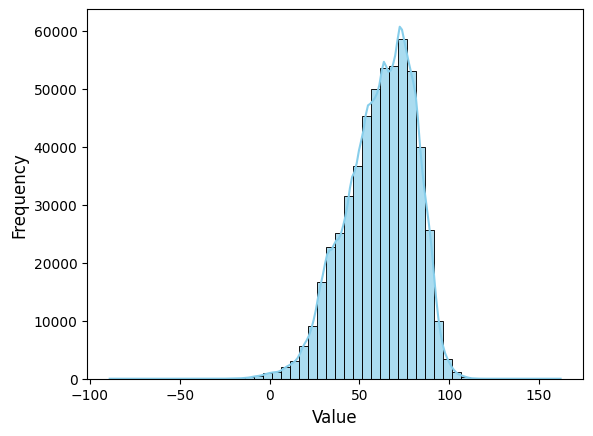

In [58]:
# Looking for a gaussian distribution
temperatures = X_train['Temperature(F)']
sns.histplot(temperatures, kde=True, bins=50, color="skyblue", edgecolor="black", alpha=0.7)
plt.xlabel("Value", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

In [59]:
#No Gaussian, fill with the mode
X_train['Temperature(F)'] = X_train['Temperature(F)'].fillna(X_train['Temperature(F)'].median())
X_val['Temperature(F)'] = X_val['Temperature(F)'].fillna(X_train['Temperature(F)'].median())
X_test['Temperature(F)'] = X_test['Temperature(F)'].fillna(X_train['Temperature(F)'].median())


### Wind Chill

<Axes: xlabel='Wind_Chill(F)', ylabel='Density'>

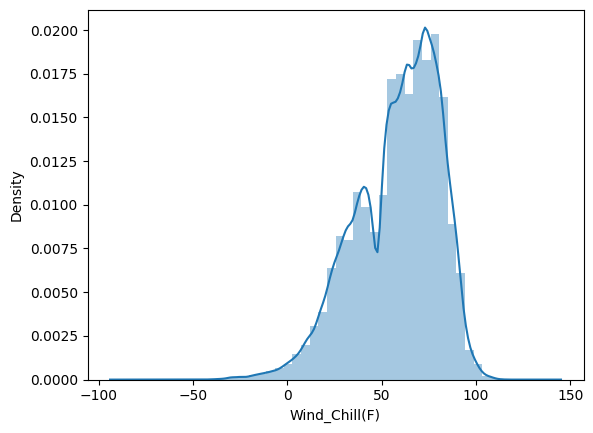

In [217]:
sns.distplot(X_train['Wind_Chill(F)'])

In [60]:
X_train['Wind_Chill(F)'] = X_train['Wind_Chill(F)'].fillna(X_train['Wind_Chill(F)'].median())
X_val['Wind_Chill(F)'] = X_val['Wind_Chill(F)'].fillna(X_train['Wind_Chill(F)'].median())
X_test['Wind_Chill(F)'] = X_test['Wind_Chill(F)'].fillna(X_train['Wind_Chill(F)'].median())

### Humidity

<Axes: xlabel='Humidity(%)', ylabel='Density'>

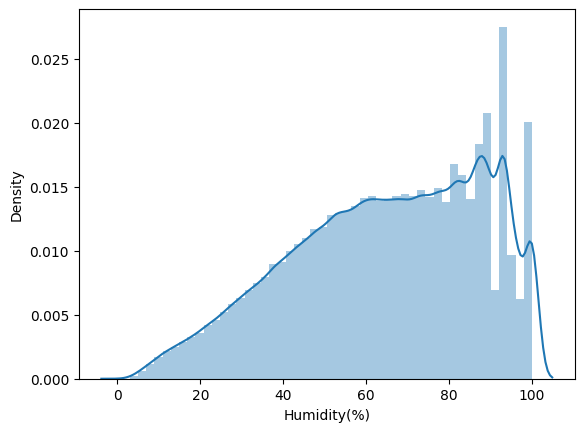

In [219]:
sns.distplot(X_train['Humidity(%)'])

In [61]:
X_train['Humidity(%)'] = X_train['Humidity(%)'].fillna(X_train['Humidity(%)'].median())
X_val['Humidity(%)'] = X_val['Humidity(%)'].fillna(X_train['Humidity(%)'].median())
X_test['Humidity(%)'] = X_test['Humidity(%)'].fillna(X_train['Humidity(%)'].median())

### Pressure

<Axes: xlabel='Pressure(in)', ylabel='Density'>

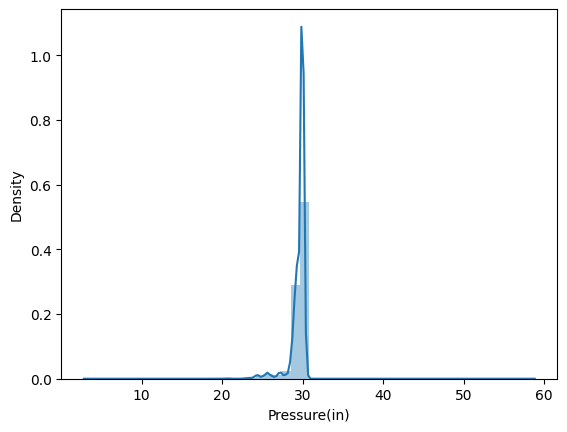

In [221]:
sns.distplot(X_train['Pressure(in)'])

In [62]:
# Data centered around a small intervall: fill with the mean
X_train['Pressure(in)'] = X_train['Pressure(in)'].fillna(X_train['Pressure(in)'].mean())
X_val['Pressure(in)'] = X_val['Pressure(in)'].fillna(X_train['Pressure(in)'].mean())
X_test['Pressure(in)'] = X_test['Pressure(in)'].fillna(X_train['Pressure(in)'].mean())

### Visibility

<Axes: xlabel='Visibility(mi)', ylabel='Density'>

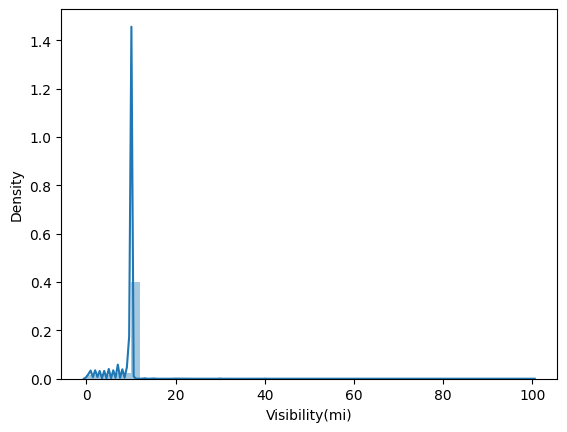

In [223]:
sns.distplot(X_train['Visibility(mi)'])

In [63]:
X_train['Visibility(mi)'] = X_train['Visibility(mi)'].fillna(X_train['Visibility(mi)'].mean())
X_val['Visibility(mi)'] = X_val['Visibility(mi)'].fillna(X_train['Visibility(mi)'].mean())
X_test['Visibility(mi)'] = X_test['Visibility(mi)'].fillna(X_train['Visibility(mi)'].mean())

### Wind Speed

<Axes: xlabel='Wind_Speed(mph)', ylabel='Density'>

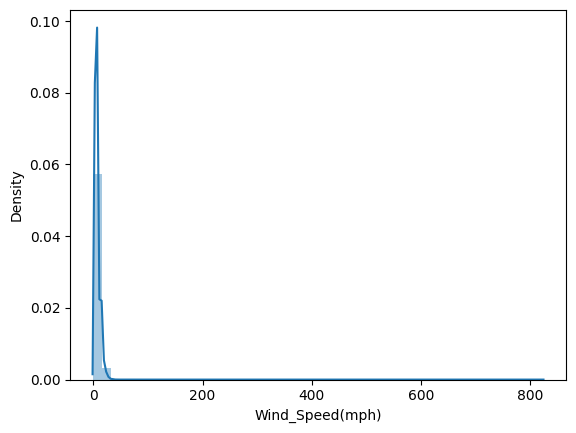

In [61]:
sns.distplot(X_train['Wind_Speed(mph)'])

In [64]:
X_train['Wind_Speed(mph)'] = X_train['Wind_Speed(mph)'].fillna(X_train['Wind_Speed(mph)'].mean())
X_val['Wind_Speed(mph)'] = X_val['Wind_Speed(mph)'].fillna(X_train['Wind_Speed(mph)'].mean())
X_test['Wind_Speed(mph)'] = X_test['Wind_Speed(mph)'].fillna(X_train['Wind_Speed(mph)'].mean())

### Precipitation

<Axes: xlabel='Precipitation(in)', ylabel='Density'>

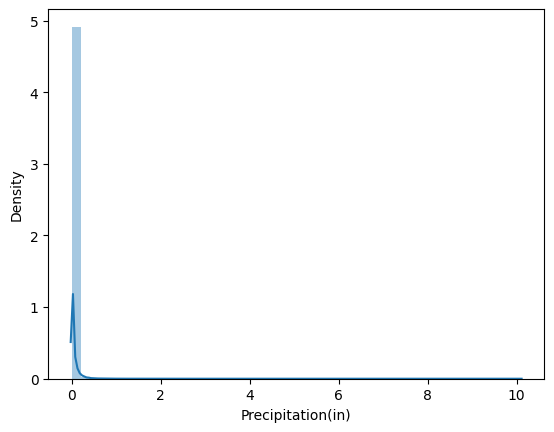

In [227]:
sns.distplot(X_train['Precipitation(in)'])

In [65]:
X_train['Precipitation(in)'] = X_train['Precipitation(in)'].fillna(X_train['Precipitation(in)'].mean())
X_val['Precipitation(in)'] = X_val['Precipitation(in)'].fillna(X_train['Precipitation(in)'].mean())
X_test['Precipitation(in)'] = X_test['Precipitation(in)'].fillna(X_train['Precipitation(in)'].mean())

### Final Check on numerical null values

In [229]:
X_train.isna().sum().to_string()

'Start_Lat                 0\nStart_Lng                 0\nEnd_Lat                   0\nEnd_Lng                   0\nDistance(mi)              0\nTemperature(F)            0\nWind_Chill(F)             0\nHumidity(%)               0\nPressure(in)              0\nVisibility(mi)            0\nWind_Speed(mph)           0\nPrecipitation(in)         0\nAmenity                   0\nBump                      0\nCrossing                  0\nGive_Way                  0\nJunction                  0\nNo_Exit                   0\nRailway                   0\nRoundabout                0\nStation                   0\nStop                      0\nTraffic_Calming           0\nTraffic_Signal            0\nTurning_Loop              0\nSunrise_Sunset            0\nCivil_Twilight            0\nNautical_Twilight         0\nAstronomical_Twilight     0\nStart_Time_Hour           0\nStart_Time_Day            0\nStart_Time_Month          0\nEnd_Time_Hour             0\nEnd_Time_Day              0\nEnd_Time_Mont

## Normalization

In [66]:
numerical_attributes = ['Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

scaler = RobustScaler() # Best suited (noisy data, skewed distributions) 
X_train[numerical_attributes] = scaler.fit_transform(X_train[numerical_attributes])
X_val[numerical_attributes] = scaler.transform(X_val[numerical_attributes])
X_test[numerical_attributes] = scaler.transform(X_test[numerical_attributes])

In [65]:
print(X_train.columns)

Index(['Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)',
       'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)',
       'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'Accident_Duration', 'Start_Time_Hour_sin',
       'Start_Time_Day_sin', 'Start_Time_Month_sin', 'End_Time_Hour_sin',
       'End_Time_Day_sin', 'End_Time_Month_sin', 'Weather_Time_Hour_sin',
       'Weather_Time_Day_sin', 'Weather_Time_Month_sin', 'Start_Time_Hour_cos',
       'Start_Time_Day_cos', 'Start_Time_Month_cos', 'End_Time_Hour_cos',
       'End_Time_Day_cos', 'End_Time_Month_cos', 'Weather_Time_Hour_cos',
       'Weather_Time_Day_cos', 'Weather_Time_Month_cos', 'grouped_State_CA',
       'grouped_State

# Dummy Classifier

In [103]:
dc = DummyClassifier()
dc.fit(X_train, y_train)
y_dummy = dc.predict(X_val)
f1_score(y_val, y_dummy, average='macro')


0.22169278680145726

# Baseline: Logistic Regression

In [104]:
log_reg = LogisticRegression( 
    max_iter=1000,        
    class_weight='balanced', # For class imbalance
    random_state=42,
    verbose=1
)

In [105]:
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_val)

In [106]:
cm = confusion_matrix(y_val, y_pred)

In [107]:
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4])

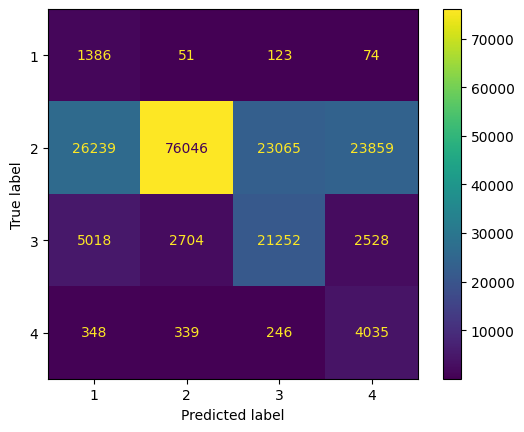

In [108]:
cm_plot.plot()
plt.show()

In [109]:
f1_score(y_val, y_pred, average='macro')

0.3828865617087692

In [110]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           1       0.04      0.85      0.08      1634
           2       0.96      0.51      0.67    149209
           3       0.48      0.67      0.56     31502
           4       0.13      0.81      0.23      4968

    accuracy                           0.55    187313
   macro avg       0.40      0.71      0.38    187313
weighted avg       0.85      0.55      0.63    187313



Not a great result, but that's expected. It's a simple model and we are under the hypotesis of linear relationship between the attributes and the target, clearly a wrong assumption

# Random Forest

In [67]:
# Balanced subsample: weights are computed from bootstrap samples for every tree
rf = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_leaf=20, random_state=42, class_weight='balanced_subsample')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)

In [68]:
cm = confusion_matrix(y_val, y_pred)

In [69]:
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4])

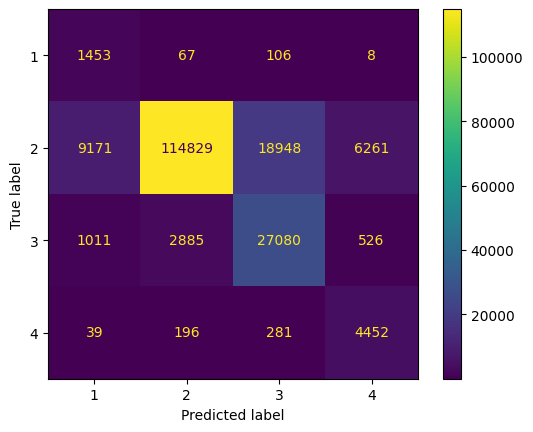

In [70]:
cm_plot.plot()
plt.show()

In [71]:
f1_score(y_val, y_pred, average='macro')

0.5805320617345111

In [72]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           1       0.12      0.89      0.22      1634
           2       0.97      0.77      0.86    149209
           3       0.58      0.86      0.70     31502
           4       0.40      0.90      0.55      4968

    accuracy                           0.79    187313
   macro avg       0.52      0.85      0.58    187313
weighted avg       0.89      0.79      0.82    187313



# Random Forest Regressor

The severity level is ordinal, treating this problem as a classic classification problem may not be the best approach

In [73]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [74]:
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=20, random_state=42, n_jobs=-1)

rf_reg.fit(X_train, y_train, sample_weight=sample_weights)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [75]:
y_pred = rf_reg.predict(X_val)
y_pred = y_pred.round().clip(1,4).astype(int)

In [76]:
cm = confusion_matrix(y_val, y_pred)

In [77]:
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4])

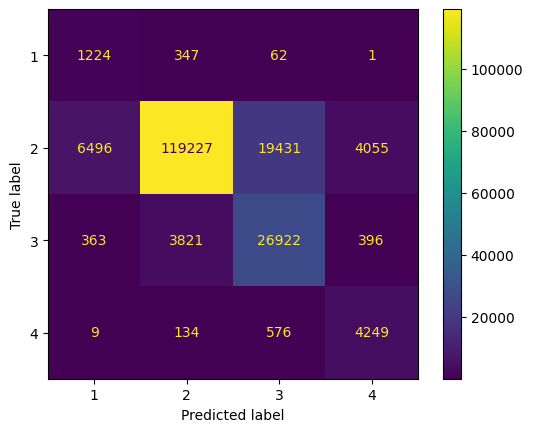

In [78]:
cm_plot.plot()
plt.show()

In [79]:
mae = mean_absolute_error(y_val, y_pred)
print(mae)

0.21528137395695973


In [80]:
f1_score(y_val, y_pred, average='macro')

0.6084160399594112

In [81]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           1       0.15      0.75      0.25      1634
           2       0.97      0.80      0.87    149209
           3       0.57      0.85      0.69     31502
           4       0.49      0.86      0.62      4968

    accuracy                           0.81    187313
   macro avg       0.54      0.81      0.61    187313
weighted avg       0.88      0.81      0.83    187313



We got similar result

As a next step we can try to tune the thresholds manually

In [82]:
y_pred = rf_reg.predict(X_val) # keep it continuous, no rounding

In [83]:
def find_trashold(y, t1, t2, t3):
    return np.where(y<t1, 1, np.where(y<t2, 2, np.where(y<t3, 3, 4)))

In [84]:
# GridSearch
best_mae = 1e9

for t1 in np.arange(1.2, 2.0, 0.1):
    for t2 in np.arange(2.,3.0,0.1):
        for t3 in np.arange(3.,3.8,0.1):
            y_tresh = find_trashold(y_pred, t1, t2, t3)
            mae = mean_absolute_error(y_val, y_tresh)

            if(mae < best_mae):
                best_mae = mae
                best_t = (t1, t2, t3)
                best_y = y_tresh

print(best_t, best_mae)

(np.float64(1.2), np.float64(2.8000000000000007), np.float64(3.7000000000000006)) 0.16067758244222238


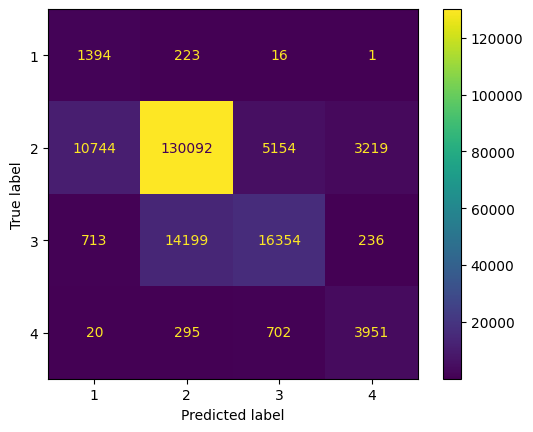

In [85]:
cm = confusion_matrix(y_val, y_tresh)
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4])
cm_plot.plot()
plt.show()


In [86]:
print(classification_report(y_val, y_tresh))

              precision    recall  f1-score   support

           1       0.11      0.85      0.19      1634
           2       0.90      0.87      0.88    149209
           3       0.74      0.52      0.61     31502
           4       0.53      0.80      0.64      4968

    accuracy                           0.81    187313
   macro avg       0.57      0.76      0.58    187313
weighted avg       0.85      0.81      0.83    187313



# Gradient Boosting Regressor

In [111]:
gb_reg = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, random_state=42)

gb_reg.fit(X_train, y_train, sample_weight=sample_weights)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",400
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged::

In [112]:
y_pred = gb_reg.predict(X_val)
y_pred = y_pred.round().clip(1,4).astype(int)

In [113]:
cm = confusion_matrix(y_val, y_pred)

In [114]:
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4])

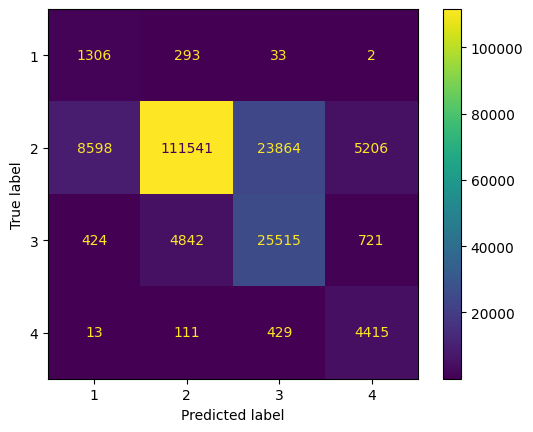

In [115]:
cm_plot.plot()
plt.show()

In [116]:
mae = mean_absolute_error(y_val, y_pred)
print(mae)

0.26874803136995296


In [117]:
f1_score(y_val, y_pred, average='macro')

0.56520079881577

In [118]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           1       0.13      0.80      0.22      1634
           2       0.96      0.75      0.84    149209
           3       0.51      0.81      0.63     31502
           4       0.43      0.89      0.58      4968

    accuracy                           0.76    187313
   macro avg       0.51      0.81      0.57    187313
weighted avg       0.86      0.76      0.79    187313



# XGBoost

In [119]:
xgb_reg = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(X_train, y_train, sample_weight=sample_weights)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [120]:
y_pred = xgb_reg.predict(X_val)
y_pred = y_pred.round().clip(1,4).astype(int)

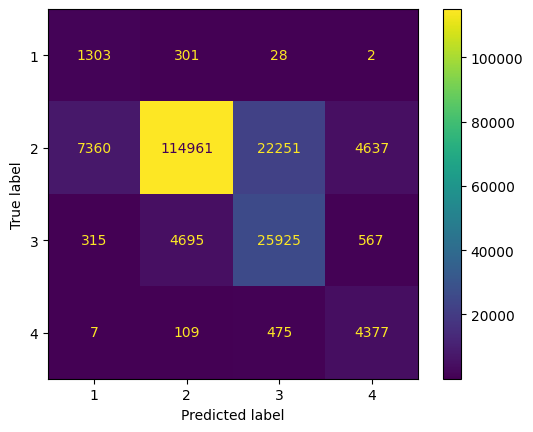

In [121]:
cm = confusion_matrix(y_val, y_pred)
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4])
cm_plot.plot()
plt.show()

In [122]:
mae = mean_absolute_error(y_val, y_pred)
print(mae)

0.24479881268251535


In [123]:
f1_score(y_val, y_pred, average='macro')

0.5868837400570162

In [124]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           1       0.15      0.80      0.25      1634
           2       0.96      0.77      0.85    149209
           3       0.53      0.82      0.65     31502
           4       0.46      0.88      0.60      4968

    accuracy                           0.78    187313
   macro avg       0.52      0.82      0.59    187313
weighted avg       0.87      0.78      0.81    187313



In [125]:
#GridSearch finetuning

best_mae = 1e9

for max_depth in [3, 4, 5]:
    for learning_rate in [0.03, 0.05, 0.1]:
        for n_estimators in [200, 400, 600]:
            xgb_reg = XGBRegressor(
                    n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
            )

            xgb_reg.fit(X_train, y_train, sample_weight=sample_weights)

            y_pred = xgb_reg.predict(X_val)
            y_pred = y_pred.round().clip(1,4).astype(int)
            mae = mean_absolute_error(y_val, y_pred)
            if mae < best_mae:
                best_mae = mae
                best_model = xgb_reg
                best_pred = y_pred
            

            


            

In [126]:
print('MAE:' + str(best_mae))

MAE:0.2467527614207236


In [127]:
f1_score(y_val, best_pred, average='macro')

0.5839396366986518

In [128]:
print(classification_report(y_val, best_pred))

              precision    recall  f1-score   support

           1       0.15      0.79      0.25      1634
           2       0.96      0.77      0.85    149209
           3       0.53      0.82      0.64     31502
           4       0.44      0.88      0.59      4968

    accuracy                           0.78    187313
   macro avg       0.52      0.81      0.58    187313
weighted avg       0.86      0.78      0.81    187313



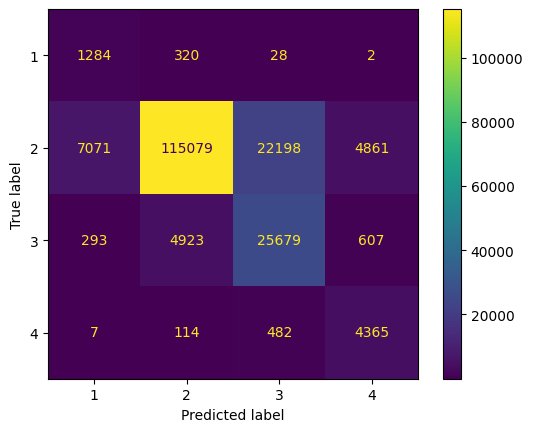

In [129]:
cm = confusion_matrix(y_val, best_pred)
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4])
cm_plot.plot()
plt.show()

# Winner: Random Forest Classifier

In [93]:
y_final = rf_reg.predict(X_test).round().clip(1,4).astype(int)

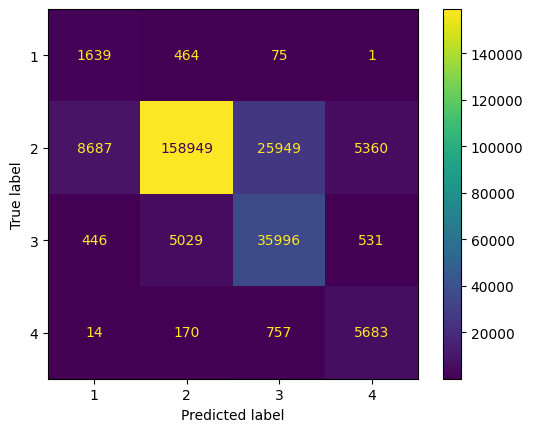

In [94]:
cm = confusion_matrix(y_test, y_final)
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4])
cm_plot.plot()
plt.show()

In [95]:
f1_score(y_test, y_final, average='macro')

0.609717237121641

In [96]:
print(classification_report(y_test, y_final))

              precision    recall  f1-score   support

           1       0.15      0.75      0.25      2179
           2       0.97      0.80      0.87    198945
           3       0.57      0.86      0.69     42002
           4       0.49      0.86      0.62      6624

    accuracy                           0.81    249750
   macro avg       0.55      0.82      0.61    249750
weighted avg       0.88      0.81      0.83    249750



# Feature importance

## Mean Reduction of Impurity

In [98]:
importances = rf_reg.feature_importances_

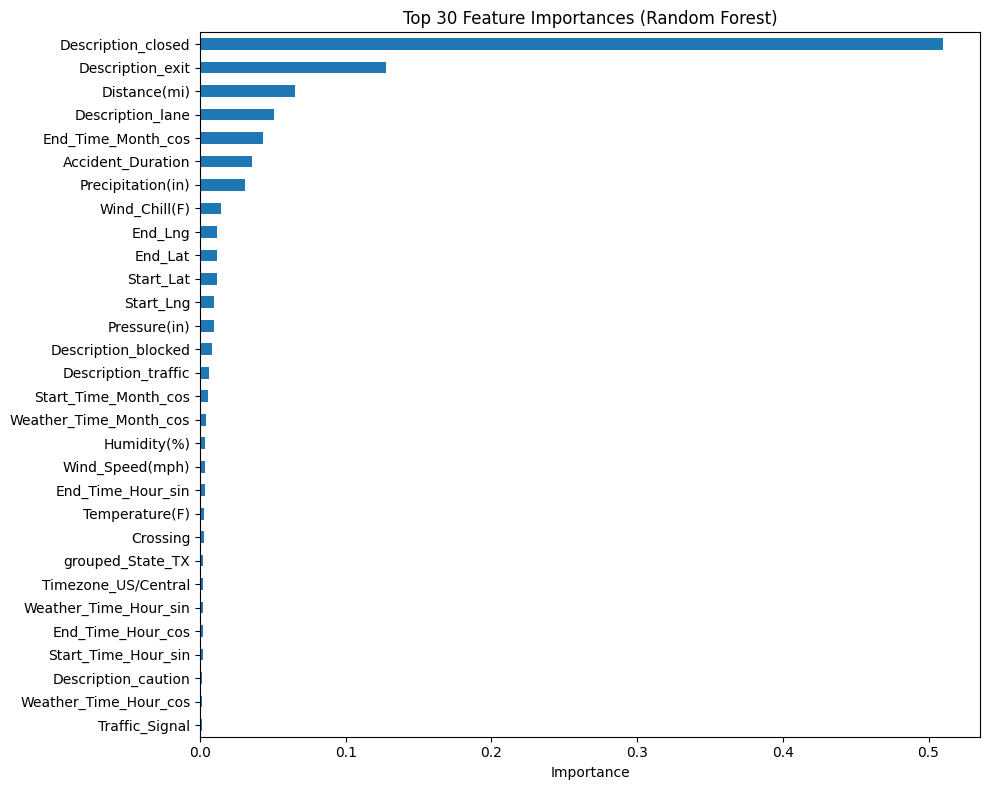

In [99]:

forest_importances = pd.Series(importances, index=X_train.columns)

top_n = 30
forest_importances.nlargest(top_n).sort_values().plot(kind='barh', figsize=(10, 8))
plt.title(f'Top {top_n} Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## SHAP

In [100]:
X_sample = X_test.sample(300, random_state=42)
explainer = shap.TreeExplainer(rf)
shap_val = explainer.shap_values(X_sample)

In [101]:
print(type(shap_val))
print(np.shape(shap_val))

<class 'numpy.ndarray'>
(300, 95, 4)


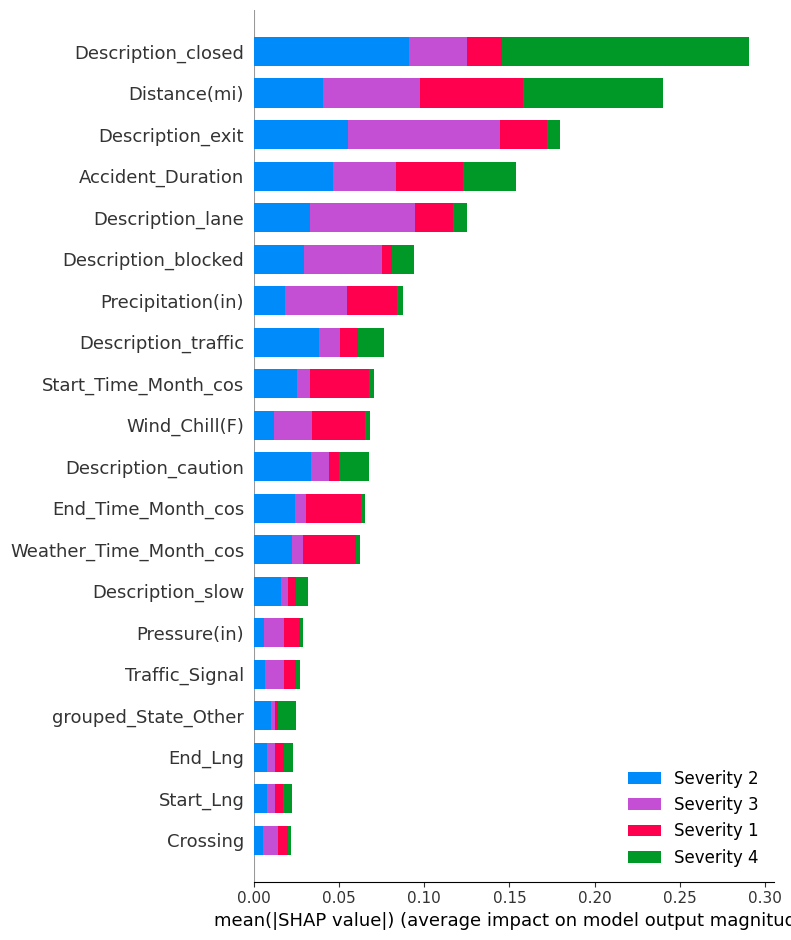

In [102]:
features = X_sample.columns.tolist()
shap.summary_plot(shap_val, X_sample, feature_names=features, plot_type='bar', class_names=['Severity 1', 'Severity 2', 'Severity 3', 'Severity 4'])
plt.show()
